# dSnow vs HS2SWE — SWE & ρ\_bulk comparison

Boxplots of observed and modelled **SWE** and **bulk snow density**
($\rho_\text{bulk} = \sum_\ell \text{SWE}_\ell / \sum_\ell h_\ell$, kg m⁻³) against the Mag25 dataset,
broken down by month (November–April).

**Data source**: `combined_layerwise_default_Mag25.nc` (all 41 Mag25 stations, 2016–2022).

- **SWE_bulk** = sum of layer SWE (= `*_swe_total` in the NC).
- **HS_bulk** = sum of layer depths (= observed HS, since both models assimilate it).
- **ρ\_bulk** = SWE\_bulk [mm] / HS\_bulk [m] = kg m⁻³.
- **ρ\_bulk observed** = `SWE_obs` [mm] / `HS_obs` [m] (biweekly snow-course days only).

Days with HS ≤ `HS_MIN_M` are excluded from ρ\_bulk to avoid noisy estimates for very shallow snowpack.

In [51]:
from pathlib import Path

# ── Data paths ────────────────────────────────────────────────────────────────
LAYERWISE_NC = Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/layerwise_data/dyn_rho_max/combined_layerwise_dyn_rho_max_default_Mag25.nc")

# Mag25 forcing — provides SWE_obs (biweekly snow-course) not stored in layerwise NC
Mag25_NC     = Path("/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc")

# ── Output ────────────────────────────────────────────────────────────────────
SAVE_DIR = Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/model_diff_rho_SWE_rho_bulk/figures_dyn_rho_max")
SAVE_FIG = True

# ── Maximum density reference lines (kg m⁻³) ─────────────────────────────────
RHO_MAX_DSNOW  = 401.0
RHO_MAX_HS2SWE = 571.6

# ── Filter settings ───────────────────────────────────────────────────────────
HS_MIN_M      = 0.05   # exclude HS ≤ 5 cm from ρ_bulk
SEASON_MONTHS = [11, 12, 1, 2, 3, 4]
MONTH_LABELS  = ["Nov", "Dec", "Jan", "Feb", "Mar", "Apr"]

In [52]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

os.chdir('/Users/jakobwerkgarner/code/mt_dsnow/')

sys.path.insert(0, str(LAYERWISE_NC.parents[2] / "HS2SWE/model"))
from plot_style import apply_style, C, FIG

warnings.filterwarnings("ignore")
apply_style()

In [53]:
# ── Load combined layerwise NC ────────────────────────────────────────────────
ds_lw = xr.open_dataset(LAYERWISE_NC, engine="netcdf4")

# Drop excluded stations
EXCLUDE_STATIONS = ["Weisfluh_Joch"]
keep = [s for s in ds_lw["station"].values if s not in EXCLUDE_STATIONS]
ds_lw = ds_lw.sel(station=keep)
print(f"Stations after exclusion: {len(ds_lw['station'])}  (dropped: {EXCLUDE_STATIONS})")
print(ds_lw)

# Station names decoded to str (NC may store as bytes |S17)
station_names = np.array([
    s.decode() if isinstance(s, bytes) else str(s)
    for s in ds_lw["station"].values
])

# ── Load SWE_obs (biweekly snow-course) from Mag25 ───────────────────────────
ds_mag  = xr.open_dataset(Mag25_NC)
SWE_obs = ds_mag["SWE"].sel(station=station_names).values  # (time, station), mm

# ── Observed HS [m] ───────────────────────────────────────────────────────────
HS_obs = ds_lw["HS_obs"].values   # (time, station), m

# ── Bulk SWE: sum of layer SWE ────────────────────────────────────────────────
SWE_dsnow  = ds_lw["dsnow_swe_total"].values    # (time, station), mm
SWE_hs2swe = ds_lw["hs2swe_swe_total"].values   # (time, station), mm

# ── Bulk HS: sum of layer depths ──────────────────────────────────────────────
hs2swe_h_bulk = np.nansum(ds_lw["hs2swe_h"].values, axis=2)  # (time, station), m
dsnow_h_bulk  = np.nansum(ds_lw["dsnow_h"].values,  axis=2)  # (time, station), m

# ── Bulk ρ = Σ SWE_layer [mm] / Σ h_layer [m]  →  kg m⁻³ ───────────────────
with np.errstate(divide="ignore", invalid="ignore"):
    rho_dsnow  = np.where(dsnow_h_bulk  > HS_MIN_M, SWE_dsnow  / dsnow_h_bulk,  np.nan)
    rho_hs2swe = np.where(hs2swe_h_bulk > HS_MIN_M, SWE_hs2swe / hs2swe_h_bulk, np.nan)
    rho_obs    = np.where(HS_obs > HS_MIN_M,         SWE_obs    / HS_obs,         np.nan)

print(f"\nRho bulk ranges:")
print(f"  dSnow  : {np.nanmin(rho_dsnow):.0f} – {np.nanmax(rho_dsnow):.0f} kg/m³")
print(f"  HS2SWE : {np.nanmin(rho_hs2swe):.0f} – {np.nanmax(rho_hs2swe):.0f} kg/m³")
print(f"  Obs    : {np.nanmin(rho_obs):.0f} – {np.nanmax(rho_obs):.0f} kg/m³  (biweekly days only)")

# ── Build long-format DataFrame ───────────────────────────────────────────────
times = pd.to_datetime(ds_lw["time"].values)

df_all = pd.DataFrame({
    "time":       np.tile(times,          len(station_names)),
    "station":    np.repeat(station_names, len(times)),
    "HS_m":       HS_obs.ravel(),
    "SWE_obs":    SWE_obs.ravel(),
    "SWE_dsnow":  SWE_dsnow.ravel(),
    "SWE_hs2swe": SWE_hs2swe.ravel(),
    "rho_obs":    rho_obs.ravel(),
    "rho_dsnow":  rho_dsnow.ravel(),
    "rho_hs2swe": rho_hs2swe.ravel(),
})
df_all["month"] = df_all["time"].dt.month
df_all = df_all[df_all["month"].isin(SEASON_MONTHS)].copy()

# SWE frame — days with a valid biweekly snow-course observation
df = df_all[
    df_all["SWE_obs"].notna() &
    (df_all["SWE_obs"] >= 0) &
    np.isfinite(df_all["SWE_dsnow"]) &
    np.isfinite(df_all["SWE_hs2swe"])
].copy()

# ρ_bulk frame — all days where HS exceeds the shallow-snow threshold
df_rho = df_all[df_all["HS_m"] > HS_MIN_M].copy()

print(f"\nSWE rows : {len(df):,}   (valid biweekly obs days)")
print(f"ρ rows   : {len(df_rho):,}  (all days with HS > {HS_MIN_M*100:.0f} cm)")
print(f"Stations : {len(station_names)}")

Stations after exclusion: 40  (dropped: ['Weisfluh_Joch'])
<xarray.Dataset> Size: 167MB
Dimensions:           (time: 2191, station: 40, layer: 78)
Coordinates:
  * time              (time) datetime64[ns] 18kB 2016-09-01T06:00:00 ... 2022...
  * station           (station) <U17 3kB 'Adelboden' 'Gadmen' ... 'Zuoz'
  * layer             (layer) int64 624B 0 1 2 3 4 5 6 ... 71 72 73 74 75 76 77
Data variables:
    HS_obs            (time, station) float32 351kB ...
    hs2swe_swe_total  (time, station) float32 351kB ...
    hs2swe_h          (time, station, layer) float32 27MB ...
    hs2swe_rho        (time, station, layer) float32 27MB ...
    hs2swe_swe        (time, station, layer) float32 27MB ...
    hs2swe_n_layers   (time, station) int16 175kB ...
    dsnow_swe_total   (time, station) float32 351kB ...
    dsnow_h           (time, station, layer) float32 27MB ...
    dsnow_rho         (time, station, layer) float32 27MB ...
    dsnow_swe         (time, station, layer) float32 27MB 

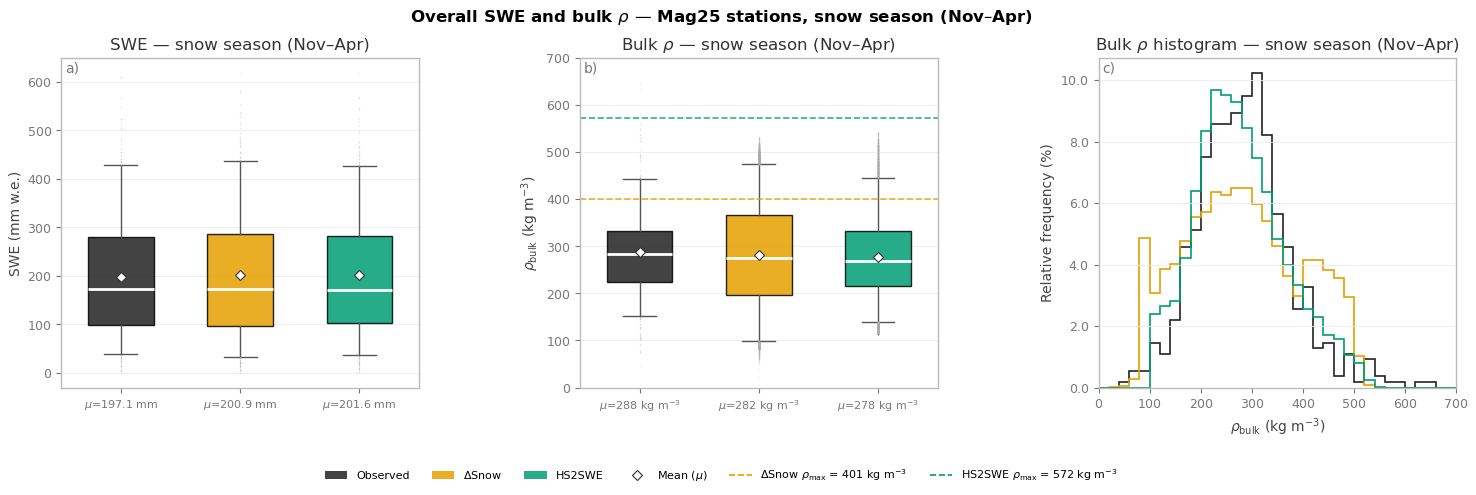

── Bulk ρ distribution statistics (Mag25, HS > 5 cm, Nov–Apr) ──

  Observed
    n          = 548
    mean       = 288.2 kg m⁻³
    median     = 282.5 kg m⁻³
    std        = 109.3 kg m⁻³
    skewness   = 4.163
    kurtosis   = 47.533  (excess, Fisher)
    p5 / p95   = 150.4 / 442.4 kg m⁻³
    IQR        = 108.5 kg m⁻³
    max        = 1680.0 kg m⁻³

  $\Delta$Snow
    n          = 15,784
    mean       = 282.2 kg m⁻³
    median     = 275.9 kg m⁻³
    std        = 113.6 kg m⁻³
    skewness   = 0.126
    kurtosis   = -0.893  (excess, Fisher)
    p5 / p95   = 98.5 / 473.8 kg m⁻³
    IQR        = 170.9 kg m⁻³
    max        = 531.0 kg m⁻³

  HS2SWE
    n          = 15,773
    mean       = 277.9 kg m⁻³
    median     = 269.0 kg m⁻³
    std        = 88.0 kg m⁻³
    skewness   = 0.445
    kurtosis   = -0.161  (excess, Fisher)
    p5 / p95   = 139.8 / 445.2 kg m⁻³
    IQR        = 115.7 kg m⁻³
    max        = 542.3 kg m⁻³


In [54]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from plot_style import add_subplot_labels

# ── Shared source config ──────────────────────────────────────────────────────
SOURCES_SWE = [
    ("SWE_obs",    "Observed",      C.OBS),
    ("SWE_dsnow",  "$\\Delta$Snow", C.DSNOW),
    ("SWE_hs2swe", "HS2SWE",        C.HS2SWE),
]
SOURCES_RHO = [
    ("rho_obs",    "Observed",      C.OBS),
    ("rho_dsnow",  "$\\Delta$Snow", C.DSNOW),
    ("rho_hs2swe", "HS2SWE",        C.HS2SWE),
]

BP_PROPS = dict(
    patch_artist=True,
    widths=0.55,
    whis=(5, 95),       # whiskers: 5th–95th percentile; box: IQR (25th–75th)
    showfliers=True,
    medianprops=dict(color="white", lw=2.0),
    whiskerprops=dict(color="#555555", lw=1.0),
    capprops=dict(color="#555555", lw=1.0),
    flierprops=dict(marker=".", markersize=2,
                    markerfacecolor="#AAAAAA", markeredgewidth=0, alpha=0.35),
)

RHO_HLINES = [
    (RHO_MAX_DSNOW,  C.DSNOW,  "--",
     f"$\\Delta$Snow $\\rho_\\mathrm{{max}}$ = {RHO_MAX_DSNOW:.0f} kg m$^{{-3}}$"),
    (RHO_MAX_HS2SWE, C.HS2SWE, "--",
     f"HS2SWE $\\rho_\\mathrm{{max}}$ = {RHO_MAX_HS2SWE:.0f} kg m$^{{-3}}$"),
]

RHO_YLIM = (0, 700)
BINS     = np.arange(0, RHO_YLIM[1] + 1, 20)


def _make_legend(sources, include_rho_max=True):
    handles = [
        mpatches.Patch(facecolor=color, alpha=0.85, label=lbl)
        for _, lbl, color in sources
    ]
    handles.append(mlines.Line2D(
        [], [], marker="D", color="none",
        markerfacecolor="white", markeredgecolor="#333333",
        markeredgewidth=0.8, markersize=5, label="Mean ($\\mu$)",
    ))
    if include_rho_max:
        for _, color, ls, label in RHO_HLINES:
            handles.append(mlines.Line2D([], [], color=color, lw=1.2, ls=ls, label=label))
    return handles


def _draw_bp(ax, data_list, colors, xlabels, ylabel, title,
             ylim=None, hlines=None, mean_fmt=".1f", unit=""):
    bps = ax.boxplot(data_list, **BP_PROPS)
    for patch, color in zip(bps["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    if hlines:
        for y, color, ls, label in hlines:
            ax.axhline(y, color=color, lw=1.2, ls=ls, alpha=0.8)

    means = [np.nanmean(d) for d in data_list]
    for i, mean in enumerate(means, start=1):
        ax.plot(i, mean, marker="D", color="white", markersize=5,
                markeredgecolor="#333333", markeredgewidth=0.8, zorder=6)

    ax.set_xticks(range(1, len(data_list) + 1))
    ax.set_xticklabels(
        [f"$\\mu$={m:{mean_fmt}}{unit}" for m in means],
        fontsize=8,
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)


# ── Overall 3-panel figure ────────────────────────────────────────────────────
fig, (ax_swe, ax_rho, ax_hist) = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(bottom=0.22, top=0.88, left=0.06, right=0.99, wspace=0.45)

_draw_bp(
    ax_swe,
    [df[col].dropna().values    for col, _, _     in SOURCES_SWE],
    [color                       for _,   _, color in SOURCES_SWE],
    [lbl                         for _,   lbl, _  in SOURCES_SWE],
    "SWE (mm w.e.)",
    "SWE — snow season (Nov–Apr)",
    mean_fmt=".1f",
    unit=" mm",
)

_draw_bp(
    ax_rho,
    [df_rho[col].dropna().values for col, _, _     in SOURCES_RHO],
    [color                        for _,   _, color in SOURCES_RHO],
    [lbl                          for _,   lbl, _  in SOURCES_RHO],
    "$\\rho_\\mathrm{bulk}$ (kg m$^{-3}$)",
    "Bulk $\\rho$ — snow season (Nov–Apr)",
    ylim=RHO_YLIM,
    hlines=RHO_HLINES,
    mean_fmt=".0f",
    unit=" kg m$^{-3}$",
)

for col, lbl, color in SOURCES_RHO:
    vals = df_rho[col].dropna().values
    counts, edges = np.histogram(vals, bins=BINS)
    ax_hist.stairs(counts / len(vals) * 100, edges, color=color, linewidth=1.2, fill=False)

ax_hist.set_xlabel("$\\rho_\\mathrm{bulk}$ (kg m$^{-3}$)")
ax_hist.set_ylabel("Relative frequency (%)")
ax_hist.set_title("Bulk $\\rho$ histogram — snow season (Nov–Apr)")
ax_hist.set_xlim(RHO_YLIM)
ax_hist.set_ylim(bottom=0)
ax_hist.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))

add_subplot_labels(np.array([ax_swe, ax_rho, ax_hist]))

fig.suptitle("Overall SWE and bulk $\\rho$ — Mag25 stations, snow season (Nov–Apr)",
             fontsize=12, fontweight="semibold")
fig.legend(handles=_make_legend(SOURCES_RHO), loc="lower center",
           ncol=6, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.01))

if SAVE_FIG:
    import os; os.makedirs(SAVE_DIR, exist_ok=True)
    fig.savefig(SAVE_DIR / "distributions_overall.png", **FIG.SAVE)
plt.show()


from scipy import stats

print("── Bulk ρ distribution statistics (Mag25, HS > 5 cm, Nov–Apr) ──")
for col, lbl, _ in SOURCES_RHO:
    vals = df_rho[col].dropna().values
    print(f"\n  {lbl}")
    print(f"    n          = {len(vals):,}")
    print(f"    mean       = {np.mean(vals):.1f} kg m⁻³")
    print(f"    median     = {np.median(vals):.1f} kg m⁻³")
    print(f"    std        = {np.std(vals):.1f} kg m⁻³")
    print(f"    skewness   = {stats.skew(vals):.3f}")
    print(f"    kurtosis   = {stats.kurtosis(vals):.3f}  (excess, Fisher)")
    print(f"    p5 / p95   = {np.percentile(vals, 5):.1f} / {np.percentile(vals, 95):.1f} kg m⁻³")
    print(f"    IQR        = {stats.iqr(vals):.1f} kg m⁻³")
    print(f"    max        = {max(vals):.1f} kg m⁻³")


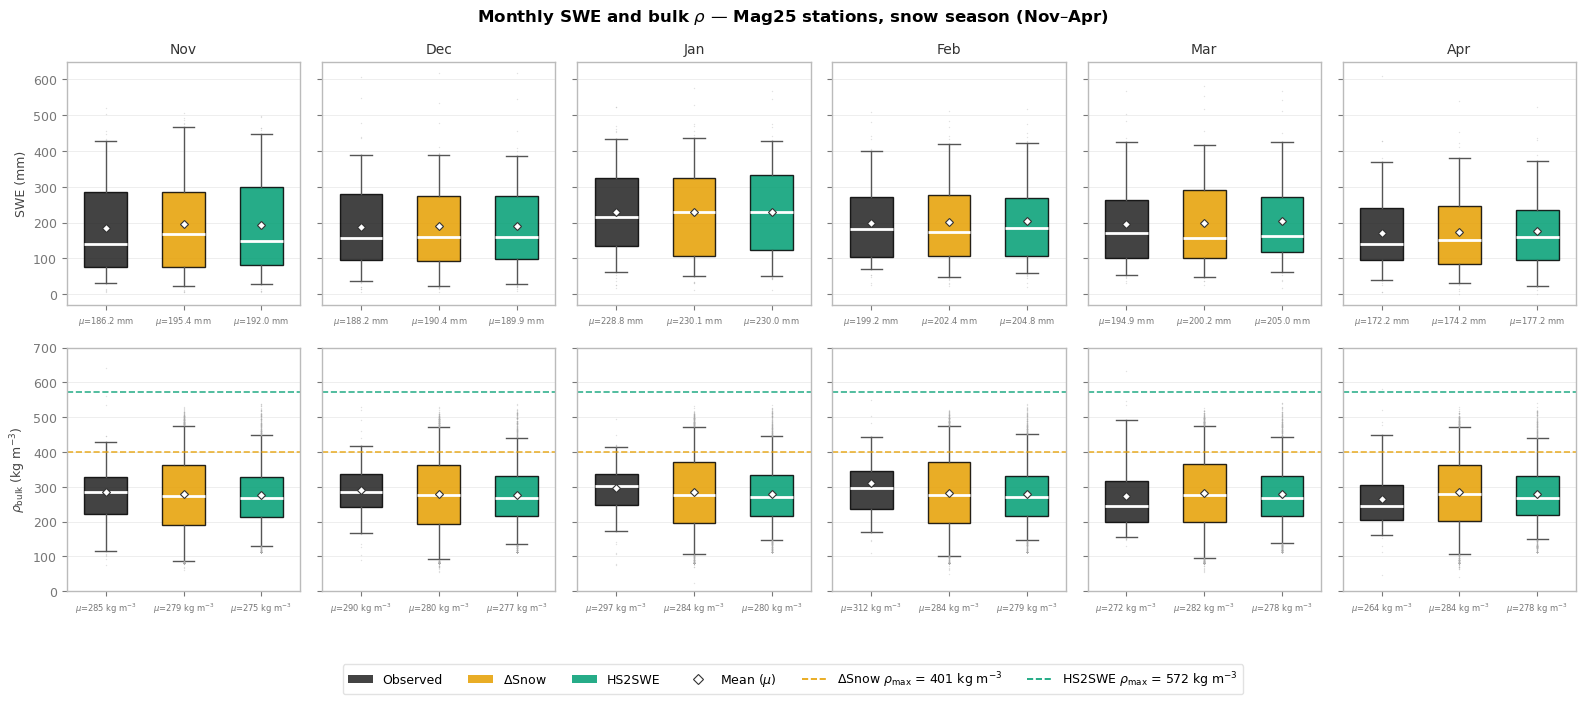

In [55]:
# ── Monthly grouped boxplots ──────────────────────────────────────────────────
ROWS = [
    (SOURCES_SWE, df,     "SWE (mm)",                         None,     False, ".1f", " mm"),
    (SOURCES_RHO, df_rho, "$\\rho_\\mathrm{bulk}$ (kg m$^{-3}$)", (0, 700), True,  ".0f", " kg m$^{-3}$"),
]

fig, axes = plt.subplots(2, 6, figsize=(16, 7), sharey="row")

for col_i, month in enumerate(SEASON_MONTHS):
    for row_i, (sources, data_df, ylabel, ylim, add_hlines, mean_fmt, unit) in enumerate(ROWS):
        ax = axes[row_i, col_i]
        dm = data_df[data_df["month"] == month]

        data_cols = [dm[col].dropna().values for col, _, _ in sources]
        bps = ax.boxplot(data_cols, **BP_PROPS)
        for patch, (_, _, color) in zip(bps["boxes"], sources):
            patch.set_facecolor(color)
            patch.set_alpha(0.85)

        tick_labels = []
        for i, ((col, _, _), d) in enumerate(zip(sources, data_cols), start=1):
            if len(d):
                mu = np.nanmean(d)
                ax.plot(i, mu, marker="D", color="white", markersize=4,
                        markeredgecolor="#333333", markeredgewidth=0.8, zorder=6)
                tick_labels.append(f"$\\mu$={mu:{mean_fmt}}{unit}")
            else:
                tick_labels.append("")

        if add_hlines:
            for y, color, ls, _ in RHO_HLINES:
                ax.axhline(y, color=color, lw=1.2, ls=ls, alpha=0.8)

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(tick_labels, fontsize=6)
        ax.set_ylabel(ylabel if col_i == 0 else "", fontsize=9)
        if col_i == 0 and ylim is not None:
            ax.set_ylim(ylim)
        if row_i == 0:
            ax.set_title(MONTH_LABELS[col_i], fontsize=10)

fig.legend(handles=_make_legend(SOURCES_RHO), loc="lower center", ncol=6,
           frameon=True, fontsize=9, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    "Monthly SWE and bulk $\\rho$ — Mag25 stations, snow season (Nov–Apr)",
    fontsize=12, fontweight="semibold",
)
fig.tight_layout(rect=[0, 0.09, 1, 1])

if SAVE_FIG:
    fig.savefig(SAVE_DIR / "boxplot_monthly.png", **FIG.SAVE)
plt.show()

In [56]:
# ── Layerwise ρ from the combined NC ─────────────────────────────────────────
# ds_lw["dsnow_rho"]  / ds_lw["hs2swe_rho"] : (time, station, layer), kg/m³
# Filter to snow season months, flatten, drop NaN/zero.

times_all = pd.to_datetime(ds_lw["time"].values)
month_all  = times_all.month

rho_lw_dsnow  = ds_lw["dsnow_rho"].values    # (time, station, layer)
rho_lw_hs2swe = ds_lw["hs2swe_rho"].values   # (time, station, layer)

# Season mask (Nov–Apr)
season_mask = np.isin(month_all, SEASON_MONTHS)   # (time,)

rho_d_season = rho_lw_dsnow[season_mask]    # (n_season_days, station, layer)
rho_h_season = rho_lw_hs2swe[season_mask]   # (n_season_days, station, layer)

def _valid(arr):
    """Flatten and keep only finite positive values."""
    v = arr.ravel()
    return v[np.isfinite(v) & (v > 0)]

rho_d = _valid(rho_d_season)
rho_h = _valid(rho_h_season)

# Per-month dictionaries
month_season = month_all[season_mask]   # month index for each season time step
rho_d_m = {}
rho_h_m = {}
for m in SEASON_MONTHS:
    mask_m = month_season == m
    rho_d_m[m] = _valid(rho_d_season[mask_m])
    rho_h_m[m] = _valid(rho_h_season[mask_m])

print(f"ΔSnow  layerwise ρ: n={len(rho_d):,}   μ={np.nanmean(rho_d):.0f} kg m⁻³")
print(f"HS2SWE layerwise ρ: n={len(rho_h):,}   μ={np.nanmean(rho_h):.0f} kg m⁻³")

ΔSnow  layerwise ρ: n=572,622   μ=385 kg m⁻³
HS2SWE layerwise ρ: n=999,984   μ=254 kg m⁻³


In [59]:
from scipy import stats as sp_stats

def stat_block(label, vals, unit=""):
    vals = vals[np.isfinite(vals)]
    print(f"  {label}  (n={len(vals):,})")
    print(f"    mean       = {np.mean(vals):.1f}{unit}")
    print(f"    median     = {np.median(vals):.1f}{unit}")
    print(f"    std        = {np.std(vals):.1f}{unit}")
    print(f"    IQR        = {sp_stats.iqr(vals):.1f}{unit}")
    print(f"    skewness   = {sp_stats.skew(vals):.3f}")
    print(f"    kurtosis   = {sp_stats.kurtosis(vals):.3f}  (excess)")
    print(f"    p5         = {np.percentile(vals,  5):.1f}{unit}")
    print(f"    p25        = {np.percentile(vals, 25):.1f}{unit}")
    print(f"    p75        = {np.percentile(vals, 75):.1f}{unit}")
    print(f"    p95        = {np.percentile(vals, 95):.1f}{unit}")
    print(f"    max        = {np.max(vals):.1f}{unit}")

# ── Bulk SWE (biweekly obs days, Nov–Apr) ─────────────────────────────────────
print("═"*60)
print("BULK SWE [mm]  —  biweekly obs days, Nov–Apr")
print("═"*60)
for col, lbl, _ in SOURCES_SWE:
    stat_block(lbl, df[col].dropna().values, unit=" mm")

# ── Bulk ρ (all days HS > 5 cm, Nov–Apr) ──────────────────────────────────────
print()
print("═"*60)
print("BULK ρ [kg m⁻³]  —  all days HS > 5 cm, Nov–Apr")
print("═"*60)
for col, lbl, _ in SOURCES_RHO:
    stat_block(lbl, df_rho[col].dropna().values, unit=" kg/m³")

# ── Layerwise ρ — overall ──────────────────────────────────────────────────────
print()
print("═"*60)
print("LAYERWISE ρ [kg m⁻³]  —  all active layers, Nov–Apr")
print("═"*60)
stat_block("ΔSnow",  rho_d, unit=" kg/m³")
stat_block("HS2SWE", rho_h, unit=" kg/m³")

# ── Layerwise ρ — per month ────────────────────────────────────────────────────
print()
print("═"*60)
print("LAYERWISE ρ [kg m⁻³]  —  seasonal breakdown (Nov → Apr)")
print("═"*60)
header = (f"{'Month':<6}{'ΔSnow μ':>10}{'ΔSnow IQR':>12}{'ΔSnow n':>10}"
          f"{'HS2SWE μ':>12}{'HS2SWE IQR':>13}{'HS2SWE n':>11}")
print(header)
print("-"*74)
for m, ml in zip(SEASON_MONTHS, MONTH_LABELS):
    d = rho_d_m[m]
    h = rho_h_m[m]
    d_mu  = np.mean(d)       if len(d) else np.nan
    h_mu  = np.mean(h)       if len(h) else np.nan
    d_iqr = sp_stats.iqr(d)  if len(d) else np.nan
    h_iqr = sp_stats.iqr(h)  if len(h) else np.nan
    max_rho   = max(d)
    print(f"{ml:<6}{d_mu:>10.1f}{d_iqr:>12.1f}{len(d):>10,}"
          f"{h_mu:>12.1f}{h_iqr:>13.1f}{len(h):>11,}")

════════════════════════════════════════════════════════════
BULK SWE [mm]  —  biweekly obs days, Nov–Apr
════════════════════════════════════════════════════════════
  Observed  (n=552)
    mean       = 197.1 mm
    median     = 172.0 mm
    std        = 122.3 mm
    IQR        = 180.2 mm
    skewness   = 0.720
    kurtosis   = -0.070  (excess)
    p5         = 38.0 mm
    p25        = 99.8 mm
    p75        = 280.0 mm
    p95        = 428.4 mm
    max        = 610.0 mm
  $\Delta$Snow  (n=552)
    mean       = 200.9 mm
    median     = 172.9 mm
    std        = 128.5 mm
    IQR        = 189.7 mm
    skewness   = 0.643
    kurtosis   = -0.304  (excess)
    p5         = 32.5 mm
    p25        = 95.8 mm
    p75        = 285.6 mm
    p95        = 435.9 mm
    max        = 616.7 mm
  HS2SWE  (n=552)
    mean       = 201.6 mm
    median     = 171.8 mm
    std        = 124.1 mm
    IQR        = 180.0 mm
    skewness   = 0.652
    kurtosis   = -0.219  (excess)
    p5         = 37.0 mm
    p25

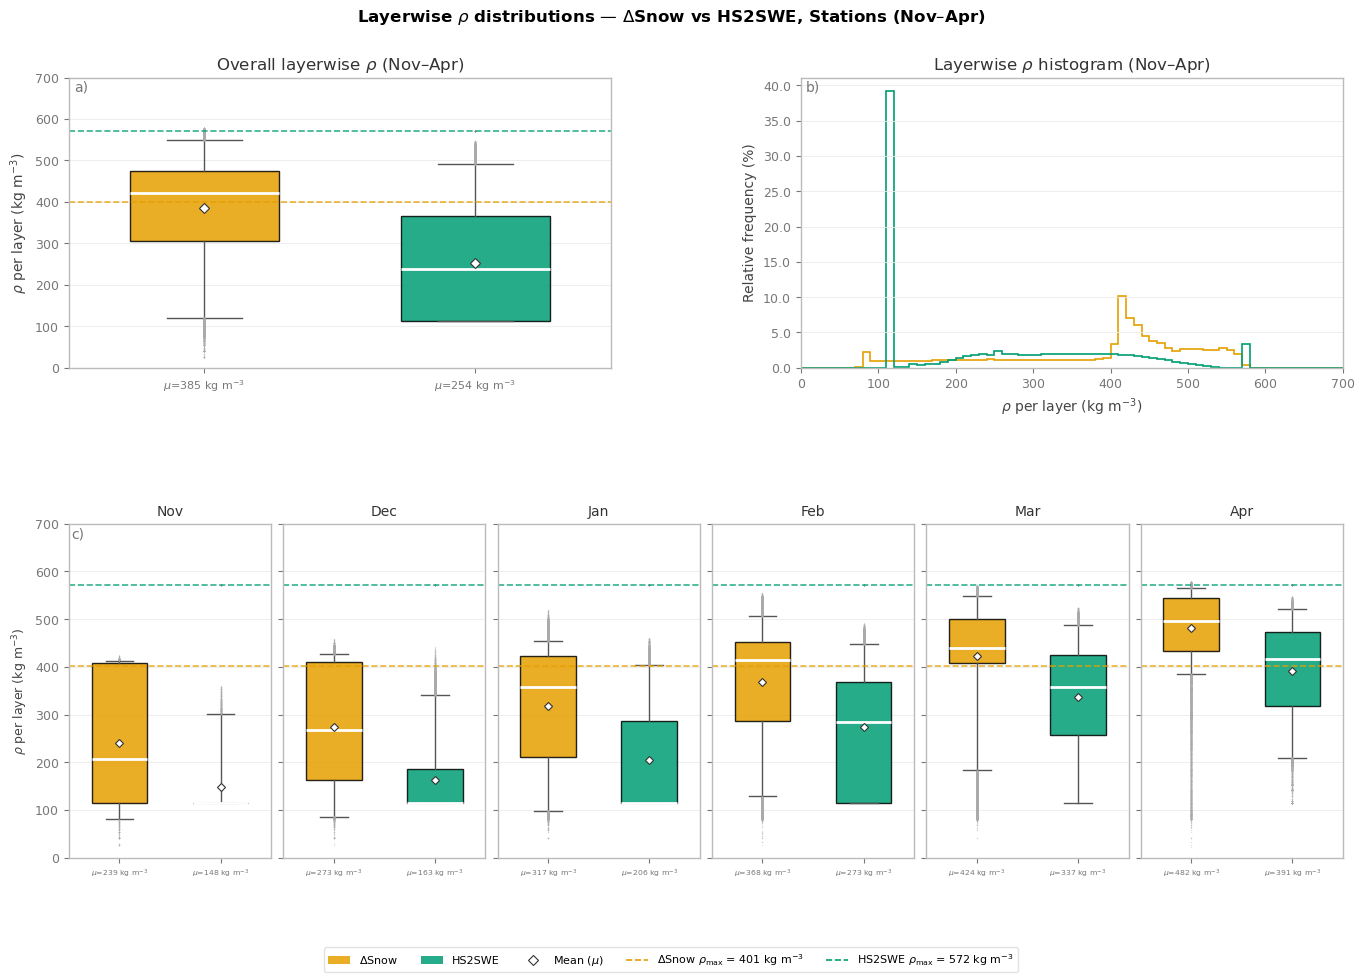

In [58]:
# ── Layerwise ρ — 3-panel figure ─────────────────────────────────────────────
SOURCES_LAYER = [
    (rho_d, "$\\Delta$Snow", C.DSNOW),
    (rho_h, "HS2SWE",        C.HS2SWE),
]
COLORS_LAYER = [C.DSNOW, C.HS2SWE]
BINS_L = np.arange(0, 710, 10)
RHO_YLIM_L = (0, 700)

fig = plt.figure(figsize=(14, 10))
gs     = gridspec.GridSpec(2, 1, figure=fig, hspace=0.50,
                            height_ratios=[1, 1.15],
                            left=0.07, right=0.98, top=0.91, bottom=0.13)
gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.35)
gs_bot = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=gs[1], wspace=0.06)

ax_box  = fig.add_subplot(gs_top[0])
ax_hist = fig.add_subplot(gs_top[1])
axes_m  = [fig.add_subplot(gs_bot[i]) for i in range(6)]

# Panel a) — overall boxplot
_draw_bp(
    ax_box,
    [rho_d, rho_h],
    COLORS_LAYER,
    [],
    "$\\rho$ per layer (kg m$^{-3}$)",
    "Overall layerwise $\\rho$ (Nov–Apr)",
    ylim=RHO_YLIM_L,
    hlines=RHO_HLINES,
    mean_fmt=".0f",
    unit=" kg m$^{-3}$",
)

# Panel b) — histogram
for vals, lbl, color in SOURCES_LAYER:
    counts, edges = np.histogram(vals, bins=BINS_L)
    ax_hist.stairs(counts / len(vals) * 100, edges,
                   color=color, linewidth=1.2, fill=False)
ax_hist.set_xlabel("$\\rho$ per layer (kg m$^{-3}$)")
ax_hist.set_ylabel("Relative frequency (%)")
ax_hist.set_title("Layerwise $\\rho$ histogram (Nov–Apr)")
ax_hist.set_xlim(RHO_YLIM_L)
ax_hist.set_ylim(bottom=0)
ax_hist.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))

# Panel c) — monthly boxplots
for ci, month in enumerate(SEASON_MONTHS):
    ax = axes_m[ci]
    d_list = [rho_d_m[month], rho_h_m[month]]

    bps = ax.boxplot(d_list, **BP_PROPS)
    for patch, color in zip(bps["boxes"], COLORS_LAYER):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for y, color, ls, _ in RHO_HLINES:
        ax.axhline(y, color=color, lw=1.2, ls=ls, alpha=0.8)

    tick_labels = []
    for i, d in enumerate(d_list, start=1):
        if len(d):
            mu = np.nanmean(d)
            ax.plot(i, mu, marker="D", color="white", markersize=4,
                    markeredgecolor="#333333", markeredgewidth=0.8, zorder=6)
            tick_labels.append(f"$\\mu$={mu:.0f} kg m$^{{-3}}$")
        else:
            tick_labels.append("")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(tick_labels, fontsize=5.5)
    ax.set_ylim(RHO_YLIM_L)
    ax.set_title(MONTH_LABELS[ci], fontsize=10)
    if ci == 0:
        ax.set_ylabel("$\\rho$ per layer (kg m$^{-3}$)", fontsize=9)
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel("")

add_subplot_labels(np.array([ax_box, ax_hist, axes_m[0]]))

fig.suptitle(
    "Layerwise $\\rho$ distributions — $\\Delta$Snow vs HS2SWE, "
    "Stations (Nov–Apr)",
    fontsize=12, fontweight="semibold",
)
fig.legend(
    handles=_make_legend(SOURCES_LAYER, include_rho_max=True),
    loc="lower center", ncol=5, fontsize=8, frameon=True,
    bbox_to_anchor=(0.5, 0.01),
)

if SAVE_FIG:
    fig.savefig(SAVE_DIR / "layerwise_rho_distributions.png", **FIG.SAVE)
plt.show()